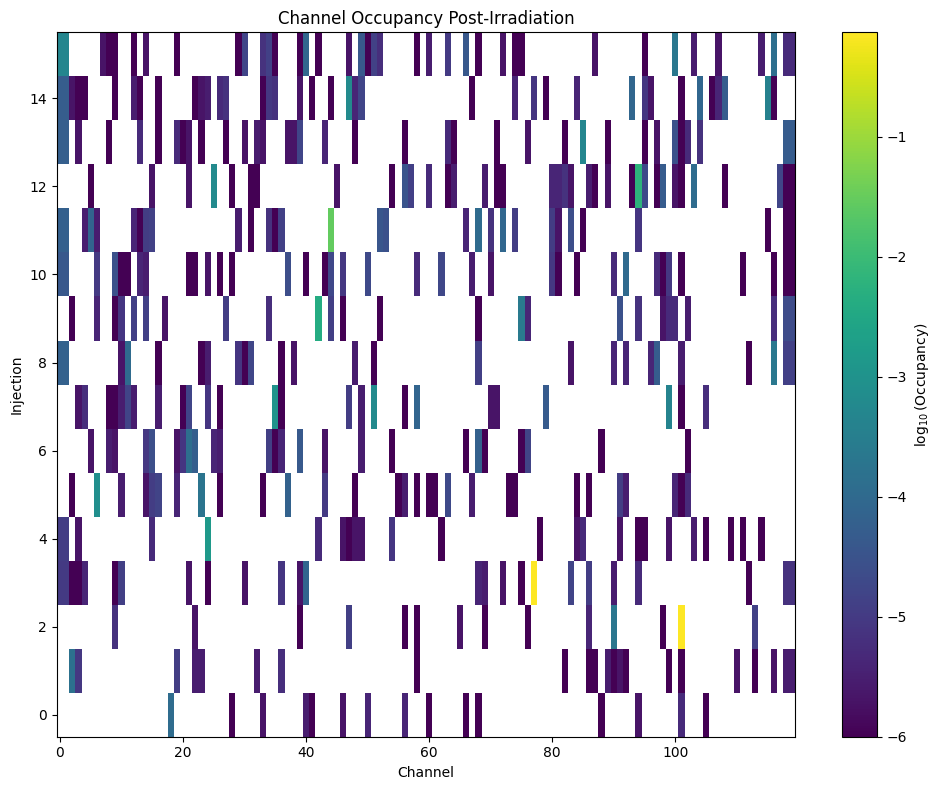

In [22]:
import uproot
import numpy as np
import matplotlib.pyplot as plt

# ROOT file
filename = (
    "/home/ekimrey/QPT_before_irradiation/"
    "post_irradiation_for_Emerson/"
    "TrackerHistos/TrackerHistos_42.root"
)

file = uproot.open(filename)

# Histogram path
hist_path = (
    "Iteration_1_PSfullTest_2026-03-12_17-23-21/"
    "Detector/Board_0/OpticalGroup_2/Hybrid_5/MPA_10/"
    "D_B(0)_O(2)_H(5)_ChannelOccupancy_Injection_0.000_MIP_Chip(10)"
)

# Get histogram
hist = file[hist_path]

# Extract original histogram
values, xedges, yedges = hist.to_numpy()

# Convert z values -> log10(z values)
# Keep x and y exactly the same
log_values = np.zeros_like(values, dtype=float)

# Avoid log10(0)
mask = values > 0
log_values[mask] = np.log10(values[mask])

# Make zero bins NaN so they are not plotted
log_values[~mask] = np.nan


# Plot
fig, ax = plt.subplots(figsize=(10, 8))

mesh = ax.pcolormesh(
    xedges,
    yedges,
    log_values.T,     # ONLY z values changed
    shading="auto",
    cmap="viridis"
)

# Color bar now shows log10(z)
cbar = plt.colorbar(mesh, ax=ax)
cbar.set_label(r"$\log_{10}(\mathrm{Occupancy})$")


# Keep original axes
ax.set_xlabel("Channel")
ax.set_ylabel("Injection")
ax.set_title("Channel Occupancy Post-Irradiation")

plt.tight_layout()

plt.savefig(
    "PostChannelOccupancy_log10_z.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

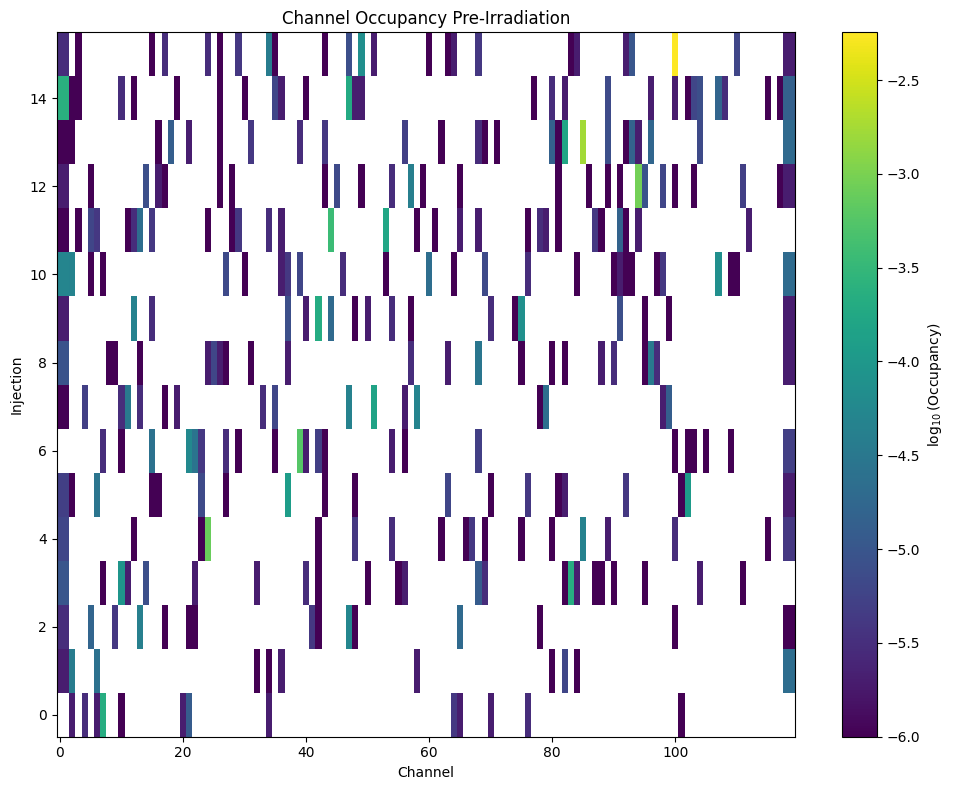

In [23]:
import uproot
import numpy as np
import matplotlib.pyplot as plt

# ROOT file
filename = (
    "PS_16_FNL-10021_2025-12-02_04h37m52s_-33C_"
    "PSfullTest_v6-22.root"
)

file = uproot.open(filename)

# Histogram path
hist_path = (
    "Detector/Board_0/OpticalGroup_1/Hybrid_3/MPA_10/"
    "D_B(0)_O(1)_H(3)_ChannelOccupancy_Injection_0.000_MIP_Chip(10)"
)

# Get histogram
hist = file[hist_path]

# Extract original histogram values
values, xedges, yedges = hist.to_numpy()

# Convert z values to log10(z values)
# Keep x and y axes unchanged
log_values = np.zeros_like(values, dtype=float)

mask = values > 0
log_values[mask] = np.log10(values[mask])

# Remove undefined log10(0) bins
log_values[~mask] = np.nan

# Plot
fig, ax = plt.subplots(figsize=(10, 8))

mesh = ax.pcolormesh(
    xedges,
    yedges,
    log_values.T,
    shading="auto",
    cmap="viridis"
)

# Color bar showing log10(z)
cbar = plt.colorbar(mesh, ax=ax)
cbar.set_label(r"$\log_{10}(\mathrm{Occupancy})$")

# Keep original axes
ax.set_xlabel("Channel")
ax.set_ylabel("Injection")
ax.set_title("Channel Occupancy Pre-Irradiation")

plt.tight_layout()

# Save
plt.savefig(
    "PrePS16_FNL_MPA15_ChannelOccupancy_log10_z.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()